In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
from PIL.ImageColor import colormap
from scipy import stats

from ipynb.fs.defs.functions import find_outliers_iqr

In [2]:
# Einlesen
df = pd.read_csv("../data/processed/master_2024.csv", sep=",", encoding="UTF-8")
df.columns

Index(['Name', 'Typ 1', 'Typ 2', 'ROR', 'erz. Hilfen pro 10000',
       '35a Hilfen pro 10000', 'Überörtlicher Träger', 'Bevölkerung 6 bis 20',
       'Anteil Kinder a.d. Gesamtbev.', 'SGB II-Quote', 'Kinderarztdichte',
       'KJP-Dichte', 'Bildungsindex', 'Bevölkerungsdichte', 'Typ'],
      dtype='object')

In [3]:
col ="Bildungsindex"
s = df[col]

desc = s.describe()
iqr = desc["75%"] - desc["25%"]
span = desc["max"] - desc["min"]
cv = desc["std"] / desc["mean"]

summary = {
    "mean": desc["mean"],
    "median": desc["50%"],
    "std": desc["std"],
    "IQR": iqr,
    "span": span,
    "IQR/span": iqr / span,
    "CV": cv
}

pd.Series(summary).round(3)

mean        2.544
median      2.452
std         0.354
IQR         0.385
span        1.517
IQR/span    0.254
CV          0.139
dtype: float64

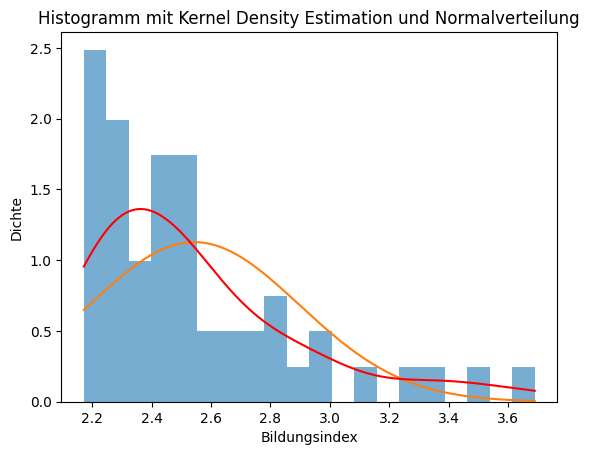

In [4]:
x = df[col].to_numpy()

plt.figure()
plt.hist(x, bins=20, density=True, alpha=0.6)

xx = np.linspace(x.min(), x.max(), 200)

mu = x.mean()
sigma = x.std(ddof=1) # Degrees fo Freedom n-1 da Strichprobe, nicht Grundgesamtheit
plt.plot(xx, stats.norm.pdf(xx, mu, sigma))


kde = stats.gaussian_kde(x)
plt.plot(xx, kde(xx), color="red")


plt.xlabel("Bildungsindex")
plt.ylabel("Dichte")
plt.title("Histogramm mit Kernel Density Estimation und Normalverteilung")
plt.show()


In [5]:
mask = find_outliers_iqr(s)

df.loc[mask, ["Name", col]]

,Name,Bildungsindex
32,Bonn,3.688975
36,Düsseldorf,3.489899
43,Köln,3.358648
47,Münster,3.308708


In [6]:
# Shapefile einlesen für Kreise/ NRW
nrw = gpd.read_file("../data/NRW-map/dvg1krs_nw.shp")

# auf Übereinstimmung der Namen prüfen
set_hilfen = set(df["Name"])
set_nrw = set(nrw["GN"])
no_match = set_hilfen.symmetric_difference(set_nrw)
print(no_match)

{'Städteregion Aachen', 'Aachen', 'Mülheim a.d. Ruhr', 'Mülheim an der Ruhr'}


In [7]:
# Fehler bereinigen
mapping = {
    "Mülheim a. d. Ruhr": "Mülheim an der Ruhr",
    'Städteregion Aachen': 'Aachen'
}

nrw.loc[:, "GN"] = (
    nrw["GN"].replace(mapping)
)


# Merge GeoData mit dem DataFrame (nach Kreisname) und fehlende Werte finden
nrw = nrw.merge(df, left_on="GN", right_on="Name", how="left")  
fehlende = nrw[nrw["35a Hilfen pro 10000"].isna()]
print(fehlende[["GN"]])

                  GN
7  Mülheim a.d. Ruhr


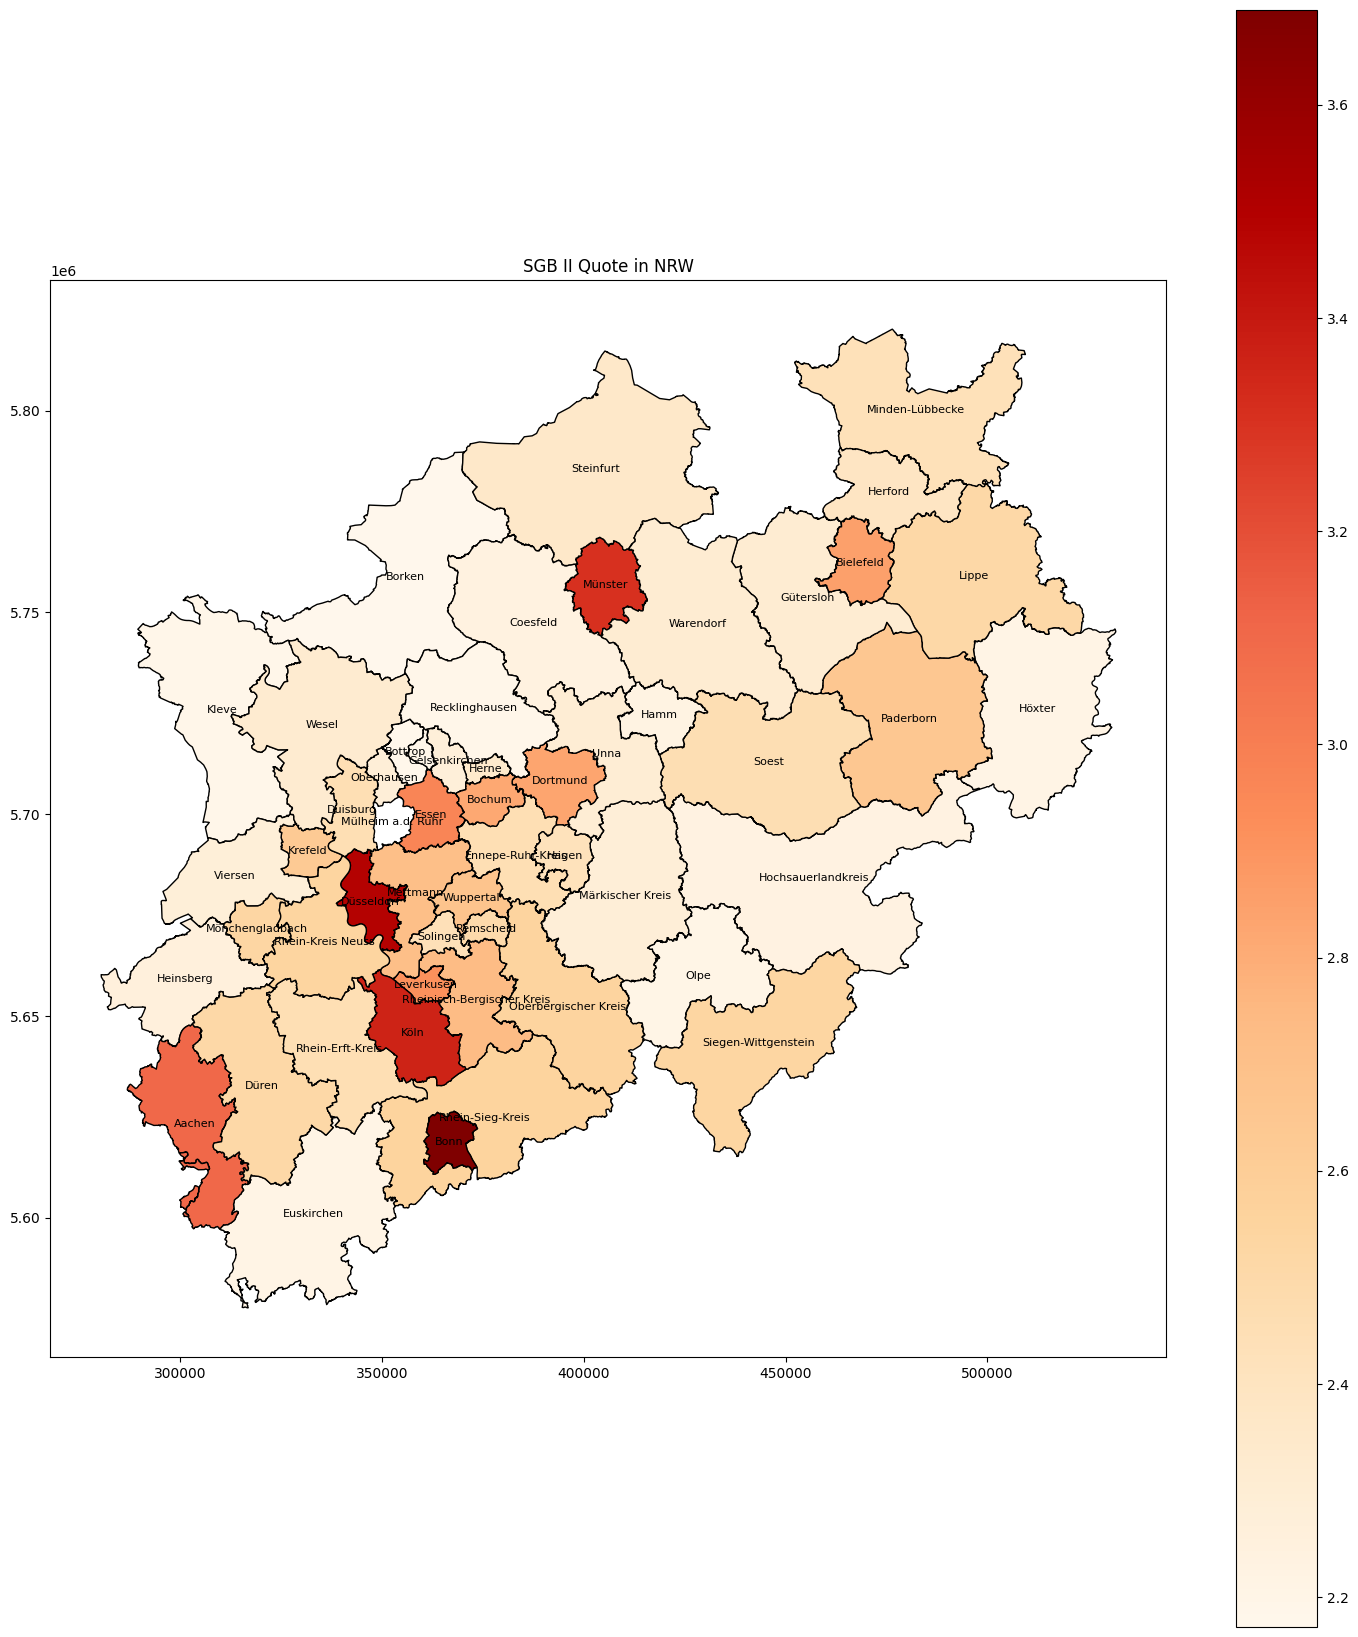

In [8]:
# Visualisierung
fig, ax = plt.subplots(1, 1, figsize=(18, 21))
nrw.plot(column=col, ax=ax, legend=True, cmap="OrRd", edgecolor="black")

for idx, row in nrw.iterrows():
    if row['geometry'].geom_type == 'Polygon':
        x, y = row['geometry'].centroid.x, row['geometry'].centroid.y
    else:  # MultiPolygon
        x, y = row['geometry'].centroid.x, row['geometry'].centroid.y
    ax.text(x, y, row['GN'], fontsize=8, ha='center', va='center')

ax.set_title("SGB II Quote in NRW")
plt.show()

In [9]:
df = df[df["Name"] != "Aachen"]

In [10]:
def summary_stats(s):
    desc = s.describe()
    iqr = desc["75%"] - desc["25%"]
    span = desc["max"] - desc["min"]
    cv = desc["std"] / desc["mean"]

    return pd.Series({
        "mean": desc["mean"],
        "median": desc["50%"],
        "std": desc["std"],
        "IQR": iqr,
        "span": span,
        "IQR/span": iqr / span,
        "CV": cv
    })

summary_by_type = (
    df
    .groupby("Typ 2")[col]
    .apply(summary_stats)
    .round(3)
)

print(summary_by_type)

Typ 2                     
Kreis             mean        2.385
                  median      2.341
                  std         0.162
                  IQR         0.269
                  span        0.558
                  IQR/span    0.482
                  CV          0.068
Kreisfreie Stadt  mean        2.734
                  median      2.648
                  std         0.430
                  IQR         0.523
                  span        1.509
                  IQR/span    0.346
                  CV          0.157
Name: Bildungsindex, dtype: float64


In [11]:
def summary_stats(s):
    desc = s.describe()
    iqr = desc["75%"] - desc["25%"]
    span = desc["max"] - desc["min"]
    cv = desc["std"] / desc["mean"]

    return pd.Series({
        "mean": desc["mean"],
        "median": desc["50%"],
        "std": desc["std"],
        "IQR": iqr,
        "span": span,
        "IQR/span": iqr / span,
        "CV": cv
    })


summary_by_type = (
    df
    .groupby("Typ 1")[col]
    .apply(summary_stats)
    .round(3)
)

print(summary_by_type)

Typ 1                     
Großer Kreis      mean        2.427
                  median      2.439
                  std         0.158
                  IQR         0.228
                  span        0.558
                  IQR/span    0.409
                  CV          0.065
Kleiner Kreis     mean        2.271
                  median      2.226
                  std         0.118
                  IQR         0.065
                  span        0.356
                  IQR/span    0.182
                  CV          0.052
Kreisfreie Stadt  mean        2.734
                  median      2.648
                  std         0.430
                  IQR         0.523
                  span        1.509
                  IQR/span    0.346
                  CV          0.157
Name: Bildungsindex, dtype: float64


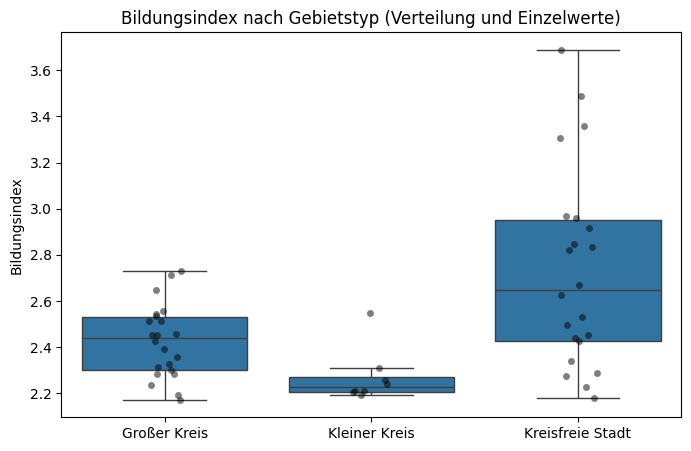

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="Typ 1",
    y=col,
    showfliers=False
)
sns.stripplot(
    data=df,
    x="Typ 1",
    y=col,
    color="black",
    alpha=0.5,
    jitter=True
)
plt.title("Bildungsindex nach Gebietstyp (Verteilung und Einzelwerte)")
plt.ylabel("Bildungsindex")
plt.xlabel("")
plt.show()

In [13]:
plt.show()
mask_by_type = (
    df
    .groupby("Typ 1")[col]
    .transform(find_outliers_iqr)
)

df.loc[mask_by_type, ["Name", "Typ 1", col]]


,Name,Typ 1,Bildungsindex
27,Oberbergischer Kreis,Kleiner Kreis,2.546434
